In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# create images folder
os.makedirs('../images', exist_ok=True)

# load dataset
df = pd.read_csv('../data/netflix_titles.csv')

# standardize columns
df.columns = df.columns.str.lower().str.strip()

# basic inspection
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


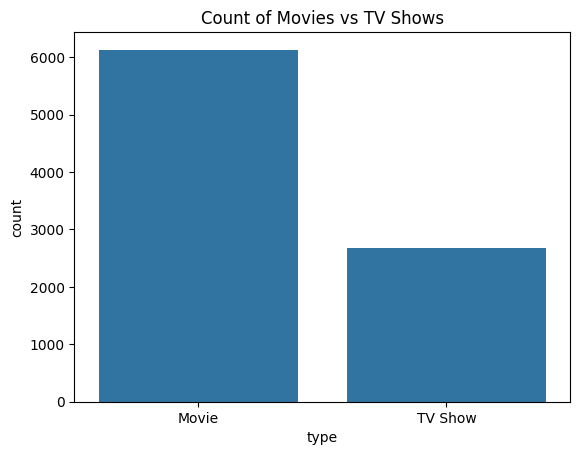

<Figure size 640x480 with 0 Axes>

In [3]:
#  1. Count by Type (Movie vs TV Show)

type_counts = df['type'].value_counts()
print(type_counts)

sns.countplot(x='type', data=df)
plt.title("Count of Movies vs TV Shows")
plt.savefig('../images/type_distribution.png')
plt.show()
plt.clf()


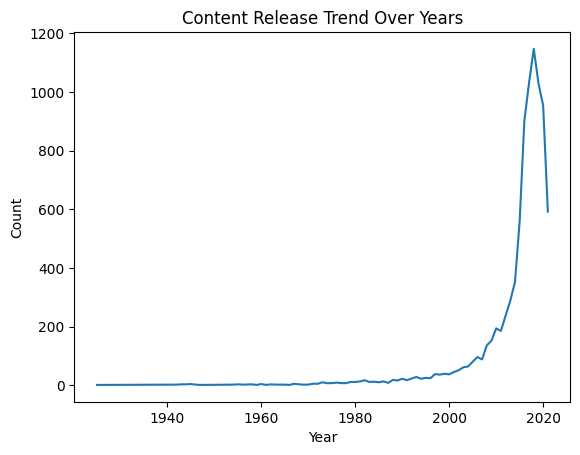

<Figure size 640x480 with 0 Axes>

In [4]:
#  2. Year Trend

df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.savefig('../images/year_trend.png')
plt.show()
plt.clf()


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


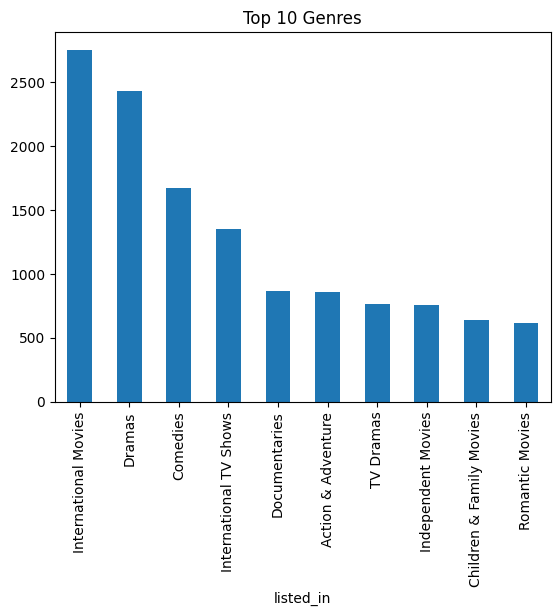

<Figure size 640x480 with 0 Axes>

In [5]:
#  3. Top Genres

# split genres
df['listed_in'] = df['listed_in'].str.split(', ')
genres = df.explode('listed_in')

top_genres = genres['listed_in'].value_counts().head(10)
print(top_genres)

top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.savefig('../images/top_genres.png')
plt.show()
plt.clf()


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\R ONE\AppData\Local\Temp\ipykernel_20120\3016562631.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)


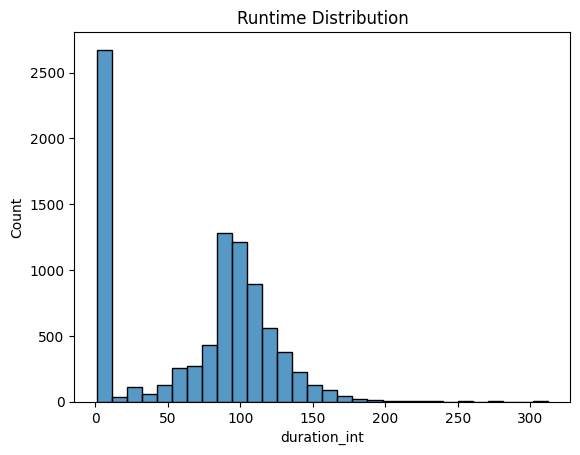

<Figure size 640x480 with 0 Axes>

In [6]:
# Runtime Distribution

# extract numeric duration
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)

sns.histplot(df['duration_int'].dropna(), bins=30)
plt.title("Runtime Distribution")
plt.savefig('../images/runtime_distribution.png')
plt.show()
plt.clf()


release_year
2012     237
2013     288
2014     352
2015     560
2021     592
2016     902
2020     953
2019    1030
2017    1032
2018    1147
Name: count, dtype: int64


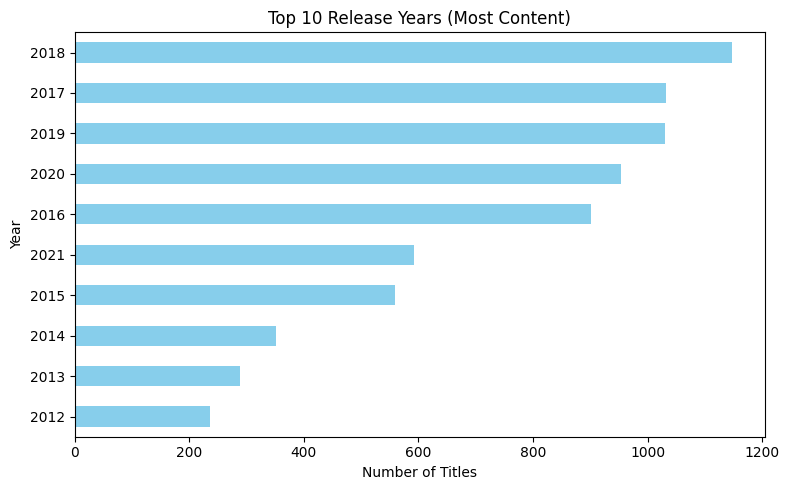

<Figure size 640x480 with 0 Axes>

In [8]:
# 5. Top 10 Years


# get top 10 years sorted by count
top_years = df['release_year'].value_counts().head(10).sort_values(ascending=True)

print(top_years)

# plot
plt.figure(figsize=(8,5))
top_years.plot(kind='barh', color='skyblue')

plt.title("Top 10 Release Years (Most Content)")
plt.xlabel("Number of Titles")
plt.ylabel("Year")

plt.tight_layout()
plt.savefig('../images/top_years.png', dpi=300)
plt.show()
plt.clf()